# Balance Between Bio-Insight and Spatial Smoothness

## Loading Packages

In [2]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

## Loading Data

In [2]:
# Column chart data
df_num = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3'],
    'SpaKnit': [13, 12, 12, 12],
    'SpatialGlue': [12, 10, 11, 11],
    'STAGATE': [2, 6, 7, 6]
}

# Read line chart data from Excel
excel_data = pd.read_excel('moran_scores_output.xlsx', sheet_name='Averages')

# Select the three methods we need
selected_methods = ['SpaKnit', 'SpatialGlue', 'STAGATE']
df_moran = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3']
}

# Extract Moran scores for the selected methods
for method in selected_methods:
    df_moran[method] = excel_data.loc[excel_data['Method'] == method].iloc[0, 1:5].tolist()

## Ploting

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


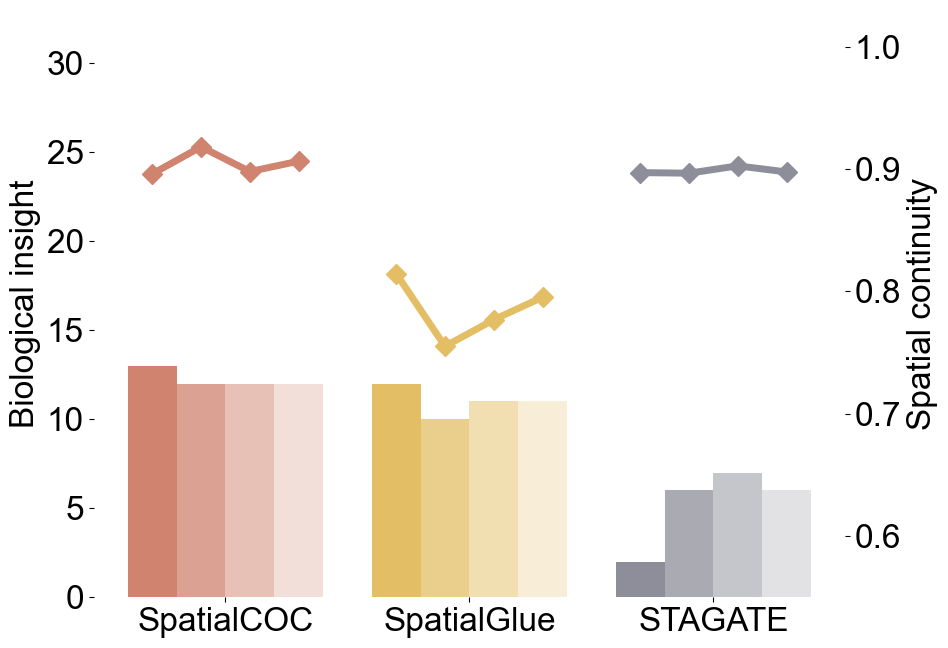

In [6]:
# Set the global font to Arial
plt.rcParams['font.family'] = 'Arial'

# Set the width of the bars
bar_width = 0.2

# Set the index
methods = selected_methods
index = np.arange(len(methods))

# Set the main color palette
colors = ['#d0836f', '#e4be64', '#8d8e99']

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 7))  # Slightly increase the figure size

# Set the unified font size
font_size = 24
plt.rcParams.update({'font.size': font_size})

# Draw the bar chart
for i, num in enumerate(df_num['Num']):
    for j, method in enumerate(methods):
        ax1.bar(index[j] - bar_width * (len(df_num['Num']) // 2 - i - 0.5), 
                df_num[method][i], 
                bar_width, 
                color=colors[j], 
                alpha=1 - i * 0.25)

# Set the primary axis (left y-axis)
ax1.set_xticks(index)
ax1.set_xticklabels(['SpatialCOC', 'SpatialGlue', 'STAGATE'])
ax1.set_ylabel('Biological insight', fontsize=font_size)
ax1.set_ylim(0, 33)  # Set the primary axis range to 0-25
ax1.tick_params(axis='both', labelsize=font_size)

# Create the secondary axis
ax2 = ax1.twinx()

# Draw the line chart (using solid square markers)
for j, method in enumerate(methods):
    x_positions = [index[j] - bar_width * (len(df_num['Num']) // 2 - i - 0.5) for i in range(len(df_num['Num']))]
    ax2.plot(x_positions, df_moran[method], 
             marker="D", linestyle='-', color=colors[j], 
             linewidth=5, markersize=10, markerfacecolor=colors[j])

# Set the secondary axis (right y-axis)
ax2.set_ylabel('Spatial continuity', fontsize=font_size)
ax2.set_ylim(0.55, 1.03)  # Set the secondary axis range to 0.55-0.95
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))  # Set the y-axis spacing to 0.1
ax2.tick_params(axis='y', labelsize=font_size)

# Remove all legends
ax1.legend().remove()
ax2.legend().remove()

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(0)
        spine.set_color('black')

# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig('Balance.png', dpi=500)
plt.savefig('Balance.eps')

# Display the figure
plt.show()

In [8]:
# Column chart data
df_num = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3'],
    'SpaKnit': [13, 12, 12, 12],
    'SpatialGlue': [12, 10, 11, 11],
    'STAGATE': [2, 6, 7, 6]
}

# Mock line chart data
df_moran = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3'],
    'SpaKnit':      [0.895985889,	0.918156328,	0.897929774,	0.906373789],
    'SpatialGlue':  [0.814461739,	0.755035103,	0.776806885,	0.795182049],
    'STAGATE':      [0.897062463,	0.89657769,	    0.902580871,	0.897592073]
}

methods = ['SpaKnit', 'SpatialGlue', 'STAGATE']

# Prepare data
bio_data = {
    'SpaKnit': df_num['SpaKnit'],
    'SpatialGlue': df_num['SpatialGlue'],
    'STAGATE': df_num['STAGATE']
}

spatial_data = {
    'SpaKnit': df_moran['SpaKnit'],
    'SpatialGlue': df_moran['SpatialGlue'],
    'STAGATE': df_moran['STAGATE']
}

def get_significance(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# ========== Spatial Continuity Significance Testing ==========
print("\n" + "="*50)
print("Spatial Continuity - Statistical Significance")
print("="*50)
print("\nPaired t-test results:")
for i, method1 in enumerate(methods[:-1]):
    for j, method2 in enumerate(methods[i+1:], i+1):
        t_stat, p_value = stats.ttest_rel(spatial_data[method1], spatial_data[method2])
        sig = get_significance(p_value)
        print(f"{method1} vs {method2}: t = {t_stat:.3f}, p = {p_value:.4f} {sig}")

        
# ========== Biological Insight Significance Testing ==========
print("="*50)
print("Biological Insight - Statistical Significance")
print("="*50)
print("\nPaired t-test results:")
for i, method1 in enumerate(methods[:-1]):
    for j, method2 in enumerate(methods[i+1:], i+1):
        t_stat, p_value = stats.ttest_rel(bio_data[method1], bio_data[method2])
        sig = get_significance(p_value)
        print(f"{method1} vs {method2}: t = {t_stat:.3f}, p = {p_value:.4f} {sig}")



Spatial Continuity - Statistical Significance

Paired t-test results:
SpaKnit vs SpatialGlue: t = 7.067, p = 0.0058 **
SpaKnit vs STAGATE: t = 1.049, p = 0.3714 ns
SpatialGlue vs STAGATE: t = -8.729, p = 0.0032 **
Biological Insight - Statistical Significance

Paired t-test results:
SpaKnit vs SpatialGlue: t = 5.000, p = 0.0154 *
SpaKnit vs STAGATE: t = 5.170, p = 0.0140 *
SpatialGlue vs STAGATE: t = 4.004, p = 0.0279 *


In [15]:

import numpy as np
from scipy import stats

# Column chart data - Biological Insight (Number of clusters)
df_num = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3'],
    'SpaKnit': [13, 12, 12, 12],
    'SpatialGlue': [12, 10, 11, 11],
    'STAGATE': [2, 6, 7, 6]
}

# Line chart data - Spatial Continuity (Moran's I)
df_moran = {
    'Num': ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3'],
    'SpaKnit':      [0.895985889, 0.918156328, 0.897929774, 0.906373789],
    'SpatialGlue':  [0.814461739, 0.755035103, 0.776806885, 0.795182049],
    'STAGATE':      [0.897062463, 0.89657769, 0.902580871, 0.897592073]
}

methods = ['SpaKnit', 'SpatialGlue', 'STAGATE']

# Prepare data
bio_data = {
    'SpaKnit': np.array(df_num['SpaKnit']),
    'SpatialGlue': np.array(df_num['SpatialGlue']),
    'STAGATE': np.array(df_num['STAGATE'])
}

spatial_data = {
    'SpaKnit': np.array(df_moran['SpaKnit']),
    'SpatialGlue': np.array(df_moran['SpatialGlue']),
    'STAGATE': np.array(df_moran['STAGATE'])
}

def cohen_d(x, y):
    """Calculate Cohen's d effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

def hedges_g(x, y):
    """Calculate Hedges' g effect size (corrected Cohen's d for small samples)"""
    d = cohen_d(x, y)
    n = len(x) + len(y)
    correction = 1 - 3 / (4 * n - 9)
    return d * correction

def get_significance(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def paired_t_test_analysis(data_dict, data_name):
    """
    Complete paired t-test analysis with:
    - t-statistic
    - degrees of freedom
    - p-value
    - 95% confidence interval for mean difference
    - Cohen's d effect size
    - Hedges' g effect size
    """
    print(f"\n{'='*70}")
    print(f"{data_name} - Complete Statistical Analysis")
    print(f"{'='*70}")
    
    results = []
    
    for i, method1 in enumerate(methods[:-1]):
        for j, method2 in enumerate(methods[i+1:], i+1):
            x = data_dict[method1]
            y = data_dict[method2]
            
            # Paired t-test
            t_stat, p_value = stats.ttest_rel(x, y)
            
            # Degrees of freedom
            df = len(x) - 1
            
            # Mean difference
            mean_diff = np.mean(x) - np.mean(y)
            
            # Standard error of mean difference
            diff = x - y
            se_diff = np.std(diff, ddof=1) / np.sqrt(len(diff))
            
            # 95% Confidence interval for mean difference
            t_critical = stats.t.ppf(0.975, df)  # Two-tailed, 95% CI
            ci_lower = mean_diff - t_critical * se_diff
            ci_upper = mean_diff + t_critical * se_diff
            
            # Effect sizes
            d = cohen_d(x, y)
            g = hedges_g(x, y)
            
            # Interpretation of effect size
            if abs(d) < 0.2:
                effect_interp = "negligible"
            elif abs(d) < 0.5:
                effect_interp = "small"
            elif abs(d) < 0.8:
                effect_interp = "medium"
            else:
                effect_interp = "large"
            
            sig = get_significance(p_value)
            
            result = {
                'Comparison': f"{method1} vs {method2}",
                'Mean1': np.mean(x),
                'Mean2': np.mean(y),
                'Mean_Diff': mean_diff,
                't_statistic': t_stat,
                'df': df,
                'p_value': p_value,
                'CI_95_lower': ci_lower,
                'CI_95_upper': ci_upper,
                'Cohens_d': d,
                'Hedges_g': g,
                'Effect_Size': effect_interp,
                'Significance': sig
            }
            results.append(result)
            
            print(f"\n{method1} vs {method2}:")
            print(f"  Mean ({method1}): {np.mean(x):.4f}")
            print(f"  Mean ({method2}): {np.mean(y):.4f}")
            print(f"  Mean Difference: {mean_diff:.4f}")
            print(f"  t-statistic: {t_stat:.4f}")
            print(f"  Degrees of freedom: {df}")
            print(f"  p-value: {p_value:.6f} {sig}")
            print(f"  95% CI of mean difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
            print(f"  Cohen's d: {d:.4f} ({effect_interp})")
            print(f"  Hedges' g: {g:.4f}")
    
    return results

# Run analysis for Spatial Continuity
spatial_results = paired_t_test_analysis(spatial_data, "Spatial Continuity (Moran's I)")

# Run analysis for Biological Insight
bio_results = paired_t_test_analysis(bio_data, "Biological Insight (Number of Clusters)")

# Summary table
print(f"\n{'='*70}")
print("SUMMARY TABLE - All Comparisons")
print(f"{'='*70}")

print("\n--- Spatial Continuity (Moran's I) ---")
print("{'Comparison':<25} {'t':<10} {'df':<6} {'p-value':<12} {'Sig':<6} {'Cohen\'s d':<12} {'95% CI':<25}")
print("-" * 100)
for r in spatial_results:
    ci_str = f"[{r['CI_95_lower']:.4f}, {r['CI_95_upper']:.4f}]"
    print(f"{r['Comparison']:<25} {r['t_statistic']:<10.4f} {r['df']:<6} {r['p_value']:<12.6f} {r['Significance']:<6} {r['Cohens_d']:<12.4f} {ci_str:<25}")

print("\n--- Biological Insight (Num Clusters) ---")
print("{'Comparison':<25} {'t':<10} {'df':<6} {'p-value':<12} {'Sig':<6} {'Cohen\'s d':<12} {'95% CI':<25}")
print("-" * 100)
for r in bio_results:
    ci_str = "[{r['CI_95_lower']:.4f}, {r['CI_95_upper']:.4f}]"
    print(f"{r['Comparison']:<25} {r['t_statistic']:<10.4f} {r['df']:<6} {r['p_value']:<12.6f} {r['Significance']:<6} {r['Cohens_d']:<12.4f} {ci_str:<25}")



Spatial Continuity (Moran's I) - Complete Statistical Analysis

SpaKnit vs SpatialGlue:
  Mean (SpaKnit): 0.9046
  Mean (SpatialGlue): 0.7854
  Mean Difference: 0.1192
  t-statistic: 7.0669
  Degrees of freedom: 3
  p-value: 0.005825 **
  95% CI of mean difference: [0.0655, 0.1729]
  Cohen's d: 6.1688 (large)
  Hedges' g: 5.3642

SpaKnit vs STAGATE:
  Mean (SpaKnit): 0.9046
  Mean (STAGATE): 0.8985
  Mean Difference: 0.0062
  t-statistic: 1.0486
  Degrees of freedom: 3
  p-value: 0.371383 ns
  95% CI of mean difference: [-0.0125, 0.0248]
  Cohen's d: 0.8318 (large)
  Hedges' g: 0.7233

SpatialGlue vs STAGATE:
  Mean (SpatialGlue): 0.7854
  Mean (STAGATE): 0.8985
  Mean Difference: -0.1131
  t-statistic: -8.7286
  Degrees of freedom: 3
  p-value: 0.003166 **
  95% CI of mean difference: [-0.1543, -0.0719]
  Cohen's d: -6.2576 (large)
  Hedges' g: -5.4414

Biological Insight (Number of Clusters) - Complete Statistical Analysis

SpaKnit vs SpatialGlue:
  Mean (SpaKnit): 12.2500
  Mean (S